#### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import  mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [67]:
import pandas as pd

df = pd.read_csv("HousingData.csv")
df.head()



,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


### Null values :

In [68]:
null_values = df.isnull().sum() / len(df) * 100
null_values = null_values.sort_values(ascending=False)
null_values

null_coloumn = ["CRIM","ZN","INDUS","CHAS","LSTAT","AGE"]

for i in null_coloumn:
    df[i].fillna(df[i].mean(), inplace=True)
    
print(f"Filling all null values :  {df.isnull().sum()}")



Filling all null values :  CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


C:\Users\Zainch-032\AppData\Local\Temp\ipykernel_10284\3627040640.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(), inplace=True)


#### Scaling data

In [69]:
Scale = MinMaxScaler()
scaled_column = ["DIS","LSTAT"]

for col in scaled_column:
    df[col] = Scale.fit_transform(df[[col]])

#### Split dataset and using Linear Regression

In [70]:
X = df[["DIS"]]
y = df["LSTAT"]

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.75,random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

#### Using metrics for Evaluation

In [ ]:
mean_square = mean_squared_error(y_pred,X_test)
R2_score = r2_score(X_test,y_pred)

print(f"Mean Square Error: {mean_square}")
print(f"R2 score of Dataset : {R2_score}")

Mean Square Error: 0.07902770723529937
R2 score of Dataset : -1.2044931871635947


#### Visualization Dataset

c:\Users\Zainch-032\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


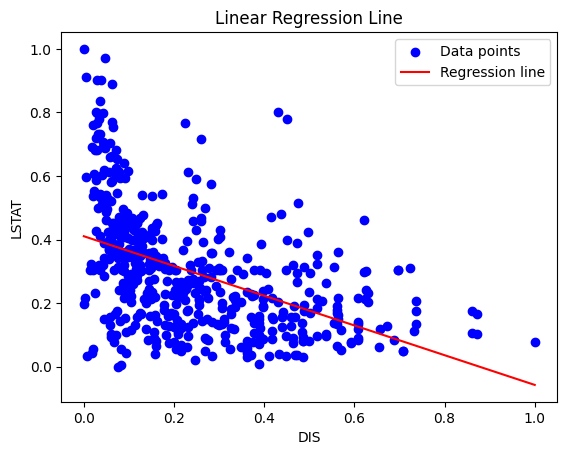

In [ ]:
x_range = np.linspace(X.min(), X.max(), 100)
y_pred = model.predict(x_range)

plt.scatter(X, y, color='blue', label='Data points')
plt.plot(x_range, y_pred, color='red', label='Regression line')
plt.xlabel("DIS")
plt.ylabel("LSTAT")
plt.legend()
plt.title("Linear Regression Line")
plt.show()